# Begin

In [1]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
import re
import pickle
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
from io import BytesIO
import sqlite3

from tqdm.notebook import tqdm

import numpy as np
import cupy as cp
import pandas as pd
import einops
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import torch
import torch.nn.functional as F

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from image_utils import *
from model_registry import *
from basis_pursuit import *
import db_utils

# Init

In [2]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/15_transformer',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/15_transformer',
 'run_path': '/home/misha/dev/mine/neurovision/run/15_transformer',
 'self_fname': '/home/misha/dev/mine/neurovision/15_transformer/15_dataset_01.ipynb',
 'self_name': '15_dataset_01',
 'subproject_name': '15_transformer',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [3]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    vocab_model_name: str = None
    vocab_model_version: int = None
    vocab_hypers: dict = None
    vocab: object = None
    batch_size: int = None
    batches_count: int = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

    def patch_size(self):
        assert self.vocab_hypers is not None, 'vocab_hypers is not initialized'
        return int(self.vocab_hypers['patch_size'])

    def vocab_size(self):
        assert self.vocab_hypers is not None, 'vocab_hypers is not initialized'
        return int(self.vocab_hypers['vocab_size'])

HP = Hyperparameters()
HP.random_seed = 42

# Bootstrap

In [4]:
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

MODEL_REGISTRY = ModelRegistry(maven_group_id=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')

Random seed=42


# Vocab

## Configure

In [5]:
HP.vocab_model_name = '15_vocab_02'
HP.vocab_model_version = 1
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'vocab_model_name': '15_vocab_02',
 'vocab_model_version': 1,
 'vocab_hypers': None,
 'vocab': None,
 'batch_size': None,
 'batches_count': None}


## Download

In [6]:
content = MODEL_REGISTRY.get_asset_content(HP.vocab_model_name, HP.vocab_model_version, asset_ext='json', asset_classifier='meta')
meta = json.loads(content.decode('utf-8'))
HP.vocab_hypers = meta['hypers']
HP.vocab = MODEL_REGISTRY.get_asset_content(HP.vocab_model_name, HP.vocab_model_version, asset_ext='npy', asset_classifier='vocab')
HP.vocab = np.load(BytesIO(HP.vocab))
pprint.pprint(HP.vocab_hypers)

{'batch_size': 100,
 'epochs_count': 100,
 'images_preprocessing': 'UNINORM',
 'learn_rate': '0.0005,plateau()',
 'optimizer': 'Adam',
 'patch_size': 5,
 'random_seed': 42,
 'vocab_size': 100}


# Images

## Load

In [7]:
IMAGES, _ = get_mnist_images(CONFIG.mnist_path, 'TRAIN')
IMAGES, scaler = preprocess_images(IMAGES, HP.vocab_hypers['images_preprocessing'])

## Decode

### Single

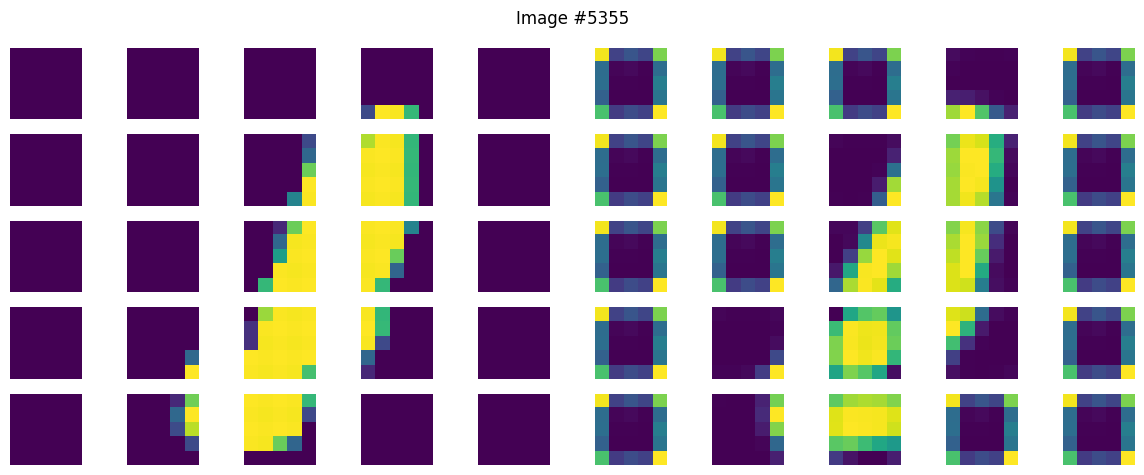

In [8]:
image_ind = RNG.choice(len(IMAGES))
patches = F.unfold(torch.tensor(einops.rearrange(IMAGES[image_ind], 'h w -> 1 h w')), kernel_size=HP.patch_size(), stride=HP.patch_size())
patches_z = bp_batch_solo(einops.rearrange(patches, 'hw p -> p hw'), HP.vocab.T)
patches_z = einops.rearrange(patches_z, '(x y) z-> x y z', x=IMAGES[0].shape[0] // HP.patch_size())
patches = einops.rearrange(patches, '(h w) (x y) -> x y h w', x=IMAGES[0].shape[0] // HP.patch_size(), h=HP.patch_size())
fig, axes = plt.subplots(patches.shape[0], patches.shape[1] * 2) # left columns show original patches, right columns - from vocab (after basis pursuit)
fig.set_figwidth(12)
for ax in axes.ravel(): ax.set_axis_off()
fig.suptitle(f'Image #{image_ind}')

for axes_row, patches_row in zip(axes, patches):
    for ax, patch in zip(axes_row, patches_row):
        ax.imshow(patch)

for axes_row, patches_z_row in zip(axes, patches_z):
    for ax, patch_z in zip(axes_row[patches.shape[0]:], patches_z_row):
        vocab_item = HP.vocab[np.argmax(patch_z)]
        ax.imshow(ArrayUtils.v2sm(vocab_item))

fig.tight_layout()

In [9]:
# ПЕРЕФОРМ словарь с учётом ограничения, что айтем при uninorm должен быть 0..1?

### Batch

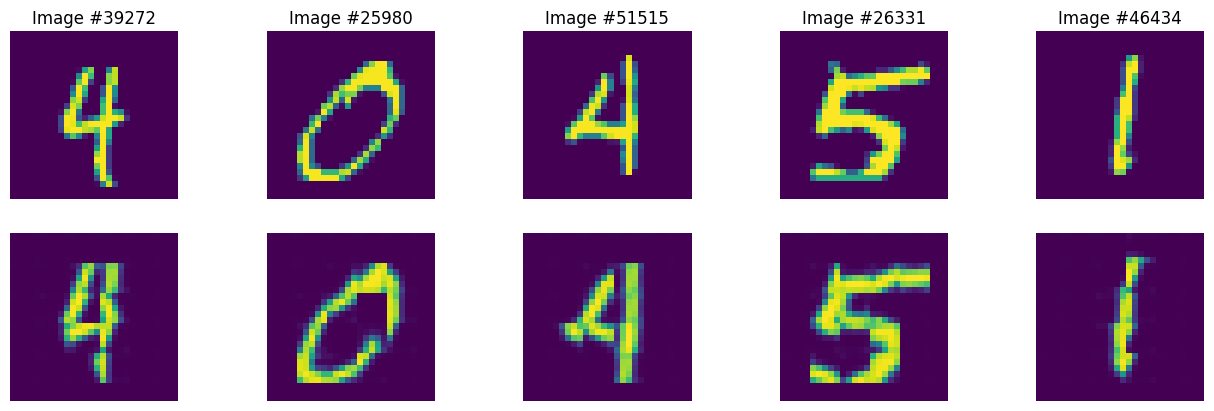

In [10]:
image_inds = RNG.choice(len(IMAGES), 5, replace=False)
fig, axes = plt.subplots(2, len(image_inds))
fig.set_figwidth(16)
# fig.set_figheight(len(image_inds) * 2)
for ax in axes.ravel(): ax.set_axis_off()

for image_ind, (ax1, ax2) in zip(image_inds, axes.T):
    image = IMAGES[image_ind]
    ax1.set_title(f'Image #{image_ind}')
    ax1.imshow(image)

    patches = F.unfold(torch.tensor(einops.rearrange(image, 'h w -> 1 h w')), kernel_size=HP.patch_size(), stride=HP.patch_size())
    patches_z = bp_batch_solo(einops.rearrange(patches, 'hw p -> p hw'), HP.vocab.T)
    patches_z = einops.rearrange(patches_z, '(y x) z-> y x z', x=image.shape[0] // HP.patch_size())

    image_hat = np.zeros_like(image)

    for y in range(patches_z.shape[0]):
        for x in range(patches_z.shape[1]):
            vocab_item = HP.vocab[np.argmax(patches_z[y,x])]
            i = lambda y: y * HP.patch_size()
            j = lambda x: x * HP.patch_size()
            image_hat[i(y):i(y+1),j(x):j(x+1)] = ArrayUtils.v2sm(vocab_item)
        
    ax2.imshow(image_hat)


In [11]:
# 45485

# Dataset

## get_db_fname

In [12]:
def get_db_fname(patch_size, vocab_size):
    fname = f'encodings_{patch_size}_{vocab_size}.db'
    fname = os.path.join(CONFIG.private_data_path, fname)
    return fname

def get_default_db_fname():
    return get_db_fname(HP.patch_size(), HP.vocab_size())

## Configure

In [13]:
HP.batch_size = 1000
HP.batches_count = 1

## Populate

### vocab_tokens and pos_tokens

In [14]:
with sqlite3.connect(get_default_db_fname(), autocommit=True) as db_con:
    token_ind = 1
    columns = defaultdict(list)
    
    for vocab_ind, vocab in enumerate(HP.vocab):
        columns['token_ind'].append(token_ind)
        token_ind += 1
        columns['vocab_ind'].append(vocab_ind)
        
        with BytesIO() as b:
            np.save(b, vocab)
            columns['data'].append(b.getvalue())
    
    pd.DataFrame(columns).to_sql('vocab_tokens', con=db_con, if_exists='replace')
    
    columns = defaultdict(list)
    
    for i in range(IMAGES.shape[1] - HP.patch_size() + 1):
        for j in range(IMAGES.shape[2] - HP.patch_size() + 1):
            columns['token_ind'].append(token_ind)
            token_ind += 1
            columns['pos_ind'].append(len(columns['pos_ind']))
            columns['i'].append(i)
            columns['j'].append(j)
            columns['i2'].append(i + HP.patch_size())
            columns['j2'].append(j + HP.patch_size())
            columns['center_i'].append(i + HP.patch_size() // 2)
            columns['center_j'].append(j + HP.patch_size() // 2)
    
    patches = F.unfold(torch.tensor(einops.rearrange(IMAGES[0], 'h w -> 1 h w')), kernel_size=HP.patch_size()) # e.g. patches.shape=(25, 576) or (49, 484)
    assert len(columns['token_ind']) == patches.shape[1]
    pd.DataFrame(columns).to_sql('pos_tokens', con=db_con, if_exists='replace')

### encodings

In [25]:
with sqlite3.connect(get_default_db_fname(), autocommit=False) as db_con:
    db_utils.drop_table_safe(db_con, 'encodings')
    df_vocab_tokens = pd.read_sql('SELECT * FROM vocab_tokens', con=db_con)
    df_pos_tokens = pd.read_sql('SELECT * FROM pos_tokens', con=db_con)
    vocab_ind_to_vocab_token_ind = dict(map(lambda t: (t.vocab_ind, t.token_ind), df_vocab_tokens[['vocab_ind', 'token_ind']].itertuples()))
    pos_ind_to_pos_token_ind = dict(map(lambda t: (t.pos_ind, t.token_ind), df_pos_tokens[['pos_ind', 'token_ind']].itertuples()))
    batches_count = len(IMAGES) // HP.batch_size + int(bool(len(IMAGES) % HP.batch_size))
    batches_count = LangUtils.coalesce(HP.batches_count, batches_count)
    
    for image_ind, batch_ind in tqdm(zip(range(0, len(IMAGES), HP.batch_size), range(batches_count)), total=batches_count):
        columns = defaultdict(list)
        batch = IMAGES[image_ind:image_ind+HP.batch_size]
        patches = F.unfold(torch.tensor(einops.rearrange(batch, 'b h w -> b 1 h w')), kernel_size=HP.patch_size()).numpy()
        patches_shape = einops.parse_shape(patches, 'b hw yx')
        patches = einops.rearrange(patches, 'b hw yx -> (b yx) hw')
        patches_z = bp_batch_solo(patches, HP.vocab.T)
        patches_z = einops.rearrange(patches_z, '(b yx) z -> b yx z', b=patches_shape['b'])
        
        for image_patches_z, batch_image_ind in zip(patches_z, range(image_ind, image_ind+HP.batch_size)): # per image cycle
            vocab_inds = np.argmax(image_patches_z, axis=-1)
            vocab_token_inds = list(map(lambda vi: vocab_ind_to_vocab_token_ind[vi.item()], vocab_inds))
            columns['vocab_token_ind'].extend(vocab_token_inds)
            pos_token_inds = list(map(lambda pi: pos_ind_to_pos_token_ind[pi.item()], np.arange(len(vocab_inds))))
            columns['pos_token_ind'].extend(pos_token_inds)
            columns['image_ind'].extend([batch_image_ind] * len(pos_token_inds))
    
        columns['std'].extend(patches.std(axis=1))
        columns['bfr'].extend((patches > 0).sum(axis=1) / (HP.patch_size() ** 2)) # binary fill ratio
        pd.DataFrame(columns).to_sql('encodings', con=db_con, if_exists='append')    
        db_con.commit()

    db_con.execute('CREATE INDEX idx_encodings_image_ind ON encodings (image_ind)')
    db_con.commit()

  0%|          | 0/1 [00:00<?, ?it/s]

## Verify

In [49]:
def verify_single(constr=None):
    with sqlite3.connect(f'file:{get_default_db_fname()}?mode=ro', uri=True) as db_con:
        df_vocab_tokens = pd.read_sql('SELECT * FROM vocab_tokens', con=db_con)
        df_pos_tokens = pd.read_sql('SELECT * FROM pos_tokens', con=db_con)
        df_image_inds = pd.read_sql(f'SELECT DISTINCT(image_ind) FROM encodings', con=db_con)
        image_ind = RNG.choice(df_image_inds.image_ind)
        df_encodings = pd.read_sql(f'SELECT * FROM encodings WHERE image_ind=? AND {LangUtils.coalesce(constr, 'True')}', con=db_con, params=[int(image_ind)])
        assert len(df_encodings) > 0, len(df_encodings)
        df_encodings = pd.merge(df_encodings, df_pos_tokens, left_on='pos_token_ind', right_on='token_ind')
        df_encodings = pd.merge(df_encodings, df_vocab_tokens, left_on='vocab_token_ind', right_on='token_ind')
        fig, axd = plt.subplot_mosaic(
            [
                ['A', 'B', 'C'],
                ['A', 'D', 'E'],
            ], 
            layout="constrained"
        )
        
        fig.set_figwidth(16)
        image = IMAGES[image_ind]
        axd['A'].set_title(f'Image #{image_ind}')
        axd['A'].imshow(image)
    
        for ind, (row_ind, ax_name) in enumerate(zip(RNG.choice(len(df_encodings), 4, replace=False), ('B', 'C', 'D', 'E'))):
            color = 'rgbm'[ind]
            df_rows = df_encodings[df_encodings.index == row_ind]
            assert len(df_rows) == 1
            df_row = next(df_rows.itertuples())
            rect = pltpatches.Rectangle((df_row.j, df_row.i), HP.patch_size(), HP.patch_size(), linewidth=1, edgecolor=color, facecolor='none')
            axd['A'].add_patch(rect)
            with BytesIO(df_row.data) as b: vocab_item = np.load(b)
            ax = axd[ax_name]
            title = '\n'.join((
                f'Row #{row_ind}, std={df_row.std:.2f}, bfr={df_row.bfr:.2f},',
                f'vocab_ind={df_row.vocab_ind}, vocab_token_ind={df_row.vocab_token_ind},',
                f'pos_ind={df_row.pos_ind}, pos_token_ind={df_row.pos_token_ind}'
            ))
            ax.set_title(title, c=color, fontdict=dict(fontsize=10))
            ax.imshow(ArrayUtils.v2sm(vocab_item))
            ax.set_axis_off()

### Single

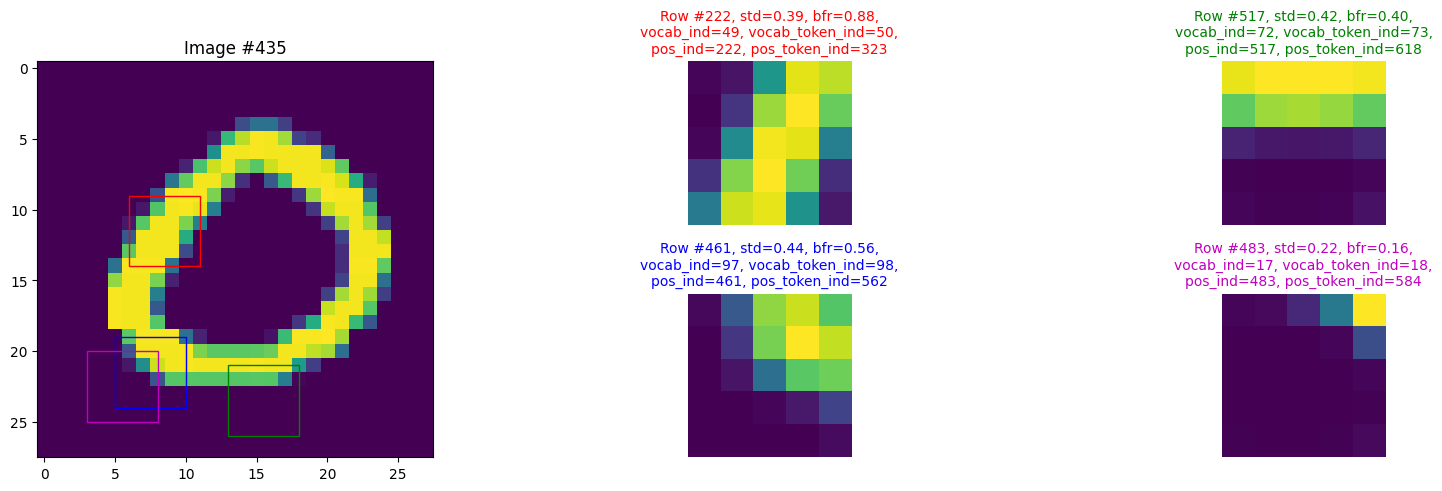

In [50]:
verify_single()

### Single (std > 0)

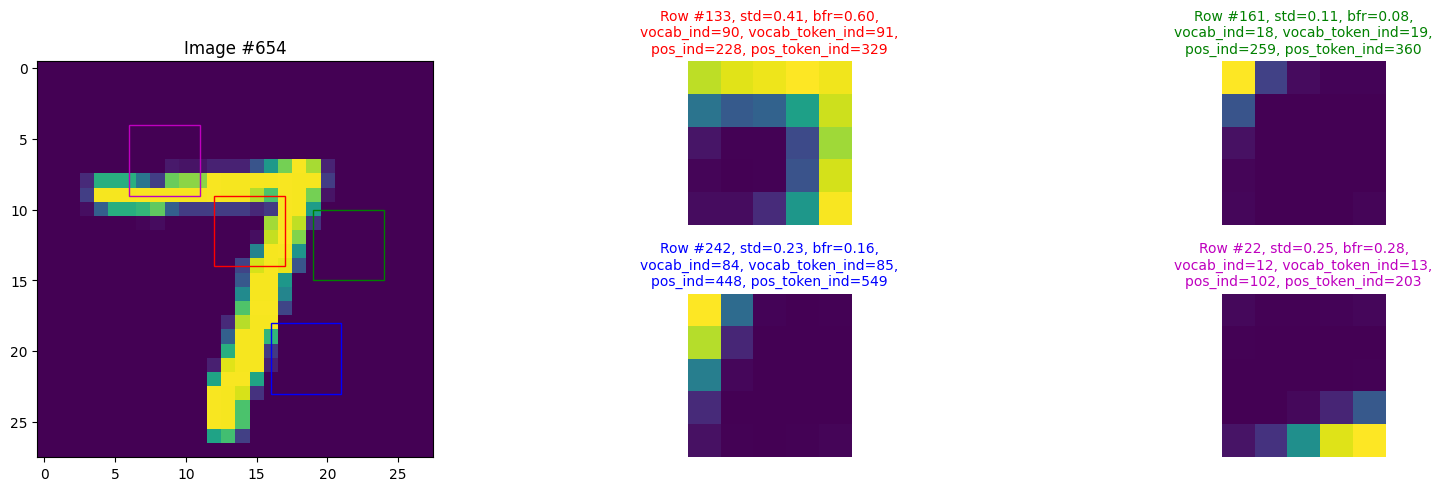

In [54]:
verify_single('std > 0')

### Single (bfr > 0.2 AND bfr < 0.9)

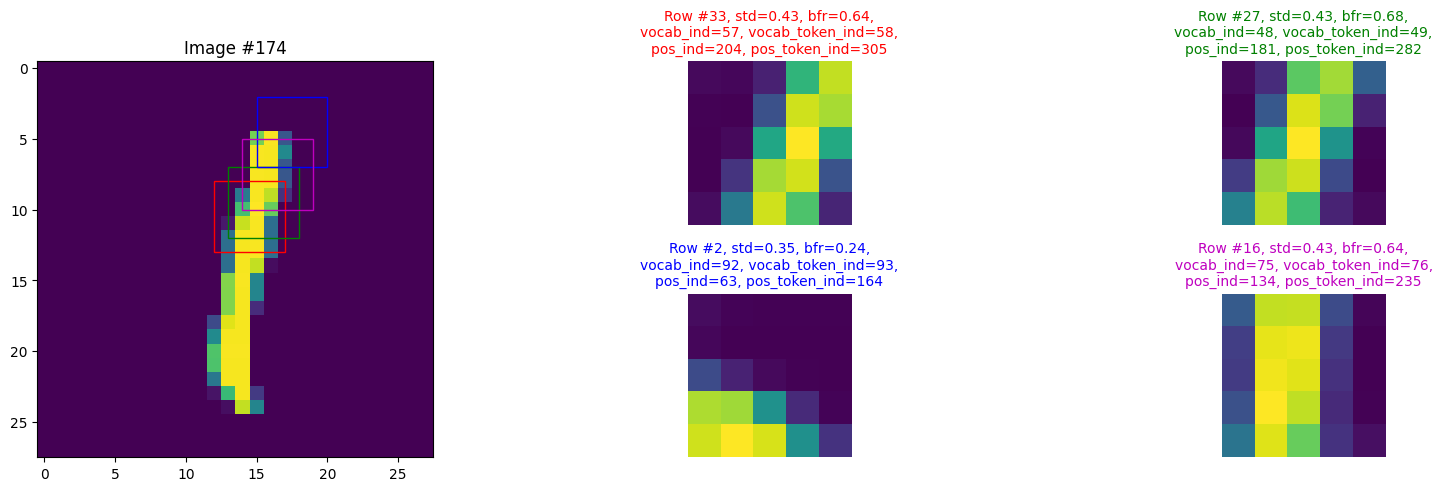

In [90]:
verify_single('bfr > 0.2 and bfr < 0.9')

### Batch

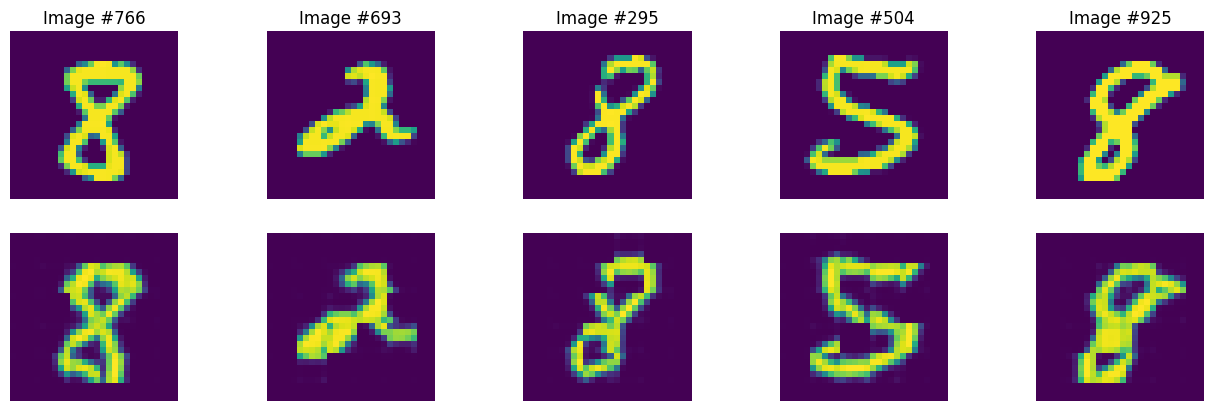

In [91]:
with sqlite3.connect(f'file:{get_default_db_fname()}?mode=ro', uri=True) as db_con:
    df_vocab_tokens = pd.read_sql('SELECT * FROM vocab_tokens', con=db_con)
    df_pos_tokens = pd.read_sql('SELECT * FROM pos_tokens', con=db_con)
    df_image_inds = pd.read_sql(f'SELECT DISTINCT(image_ind) FROM encodings', con=db_con)
    image_inds = RNG.choice(df_image_inds.image_ind, 5, replace=False)
    df_encodings = pd.read_sql(f'SELECT * FROM encodings WHERE image_ind IN ({','.join(["?"] * len(image_inds))})', con=db_con, params=list(map(int, image_inds)))
    df_encodings = pd.merge(df_encodings, df_pos_tokens, left_on='pos_token_ind', right_on='token_ind')
    df_encodings = pd.merge(df_encodings, df_vocab_tokens, left_on='vocab_token_ind', right_on='token_ind')
    fig, axes = plt.subplots(2, len(image_inds))
    fig.set_figwidth(16)
    for ax in axes.ravel(): ax.set_axis_off()
    
    for image_ind, (ax1, ax2) in zip(image_inds, axes.T):
        image = IMAGES[image_ind]
        ax1.set_title(f'Image #{image_ind}')
        ax1.imshow(image)
    
        image_hat = np.zeros_like(image)
    
        for i in range(0, image.shape[0] - HP.patch_size(), HP.patch_size()):
            for j in range(0, image.shape[1] - HP.patch_size(), HP.patch_size()):
                df_row = df_encodings[(df_encodings.image_ind == image_ind) & (df_encodings.i == i) & (df_encodings.j == j)]
                assert len(df_row) == 1
                with BytesIO(df_row.iloc[0].data) as b: vocab_item = np.load(b)
                image_hat[i:i+HP.patch_size(),j:j+HP.patch_size()] = ArrayUtils.v2sm(vocab_item)
            
        ax2.imshow(image_hat)   